# PSO Parameter Evaluation — Simulated vs Real Trajectories

Loads the PSO-optimised parameters from the results JSON, runs a forward
simulation starting from the real initial state of each trajectory, and
plots simulated vs real observations side-by-side.

**No NPE / FNPE** — purely the physics model driven by PSO params.

In [1]:
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

sys.path.insert(0, os.path.abspath('..'))

os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')
import jax
import jax.numpy as jnp

from simulation.VehicleModel import vehicle_RK4x, vehicle_fy

print(f'JAX backend : {jax.default_backend()}')
print(f'JAX devices : {jax.devices()}')

JAX backend : cpu
JAX devices : [CpuDevice(id=0)]


In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
# Point this at whichever results file you want to evaluate.
# Linear-scale run:
# RESULTS_JSON = Path('../notebooks/experiments/pso_global_optimization_results.json')
# Log-scale run (comment out the line above and uncomment below):
RESULTS_JSON = Path('../notebooks/experiments/pso_global_log_optimization_results.json')

DATA_DIR   = Path('../../data/measurements')   # directory with measurement CSVs
START_IDX  = 50     # same value used during optimisation
T_SEG      = 800    # same value used during optimisation
SAVE_FIGS  = False  # set True to save PNG files alongside the notebook
FIG_DIR    = Path('figures/pso_eval')
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# ── Load PSO results ─────────────────────────────────────────────────────────
with open(RESULTS_JSON) as f:
    results = json.load(f)

global_params = results['global_params']
traj_params   = results['trajectory_params']   # list of {trajectory, surface, params}

print(f'Method : {results["method"]}')
print(f'Timestamp : {results["timestamp"]}')
print(f'Final error : {results["final_error"]:.6f}')
print(f'Log scale : {results.get("log_scale", False)}')
print()
print('Global params:')
for k, v in global_params.items():
    print(f'  {k:<20s}: {v:.6g}')

Method : Advanced PSO — lbest→gbest, inertia schedule, LHS init, stagnation reinit, Powell polish
Timestamp : 2026-03-13T11:37:41.195875
Final error : 0.184835
Log scale : True

Global params:
  mass                : 1200
  Inertia_z           : 1440.46
  Inertia_tire        : 5
  Inertia_engine      : 0.05
  air_resistance      : 0.179352
  c_1y                : 2.00316e+06
  c_2y                : 9.99031e+06
  C_y                 : 5
  E_y                 : -2.05226
  C_roll1             : 0.05
  C_roll2             : 0.000118723
  radius_tire         : 0.313834
  c_1x                : 3.80123e+07
  c_2x                : 83623.5
  C_x                 : 3.9736
  E_x                 : -14.9998


In [4]:
# ── Load & prepare real trajectories ─────────────────────────────────────────
def classify_surface(stem):
    s = stem.lower()
    if 'asphalt' in s: return 'Asphalt'
    if 'beton'   in s: return 'Concrete'
    if 'basalt'  in s: return 'Basalt'
    return 'Unknown'

def load_trajectory(csv_path, start_idx, T_seg):
    df = pd.read_csv(csv_path)
    T  = min(T_seg, len(df) - start_idx)
    sl = slice(start_idx, start_idx + T)

    y_real = np.zeros((T, 9), dtype=np.float32)
    y_real[:, 0] = df['Rate_Body_Z'].values[sl] * np.pi / 180.0
    y_real[:, 1] = df['INS_Vel_Body_X'].values[sl]
    y_real[:, 2] = df['INS_Vel_Body_Y'].values[sl]
    y_real[:, 3] = df['Acc_Body_X'].values[sl]
    y_real[:, 4] = df['Acc_Body_Y'].values[sl]
    y_real[:, 5] = df['Tire_Rate_FL'].values[sl]
    y_real[:, 6] = df['Tire_Rate_FR'].values[sl]
    y_real[:, 7] = df['Tire_Rate_RL'].values[sl]
    y_real[:, 8] = df['Tire_Rate_RR'].values[sl]

    controls = {
        'steer_ang'        : jnp.array(np.deg2rad(df['Steer_Angle'].values[sl]),      dtype=jnp.float32),
        'engine_torque'    : jnp.array(df['Engine_Torque'].values[sl],                dtype=jnp.float32),
        'break_torque'     : jnp.array(df['Break_Pressure'].values[sl],               dtype=jnp.float32),
        'gear_transmission': jnp.array(df['Gear_Transmission'].values[sl],            dtype=jnp.float32),
    }
    return y_real, controls, T

csv_files  = sorted(DATA_DIR.glob('*.csv'))
trajectories = []
for f in csv_files:
    y_real, controls, T = load_trajectory(f, START_IDX, T_SEG)
    trajectories.append(dict(name=f.stem, surface=classify_surface(f.stem),
                             y_real=y_real, controls=controls, T=T))
    print(f'  {f.stem}  surface={trajectories[-1]["surface"]}  T={T}')

print(f'\nLoaded {len(trajectories)} trajectories')

  Jeversen_2021_12_15_112145_Asphalt-Vollbremsung  surface=Asphalt  T=800
  Jeversen_2021_12_15_112328_Asphalt-Vollbremsung  surface=Asphalt  T=800
  Jeversen_2021_12_15_125650_Beton-Vollbremsung  surface=Concrete  T=800
  Jeversen_2021_12_15_125936_Beton-Vollbremsung  surface=Concrete  T=800
  Jeversen_2021_12_15_134709_Basalt-Vollbremsung  surface=Basalt  T=800
  Jeversen_2021_12_15_134858_Basalt-Vollbremsung  surface=Basalt  T=800
  Jeversen_2022_10_12_110132  surface=Unknown  T=800

Loaded 7 trajectories


In [5]:
# ── JIT-compiled simulator (same as in run_pso_global.py) ────────────────────
@jax.jit
def simulate_trajectory_jit(p_inf, state0, controls_arr, params_arr, timesteps, radius_tire_val):
    params = dict(
        c_1x=params_arr[0], c_2x=params_arr[1],
        c_1y=params_arr[2], c_2y=params_arr[3],
        C_x =params_arr[4], C_y =params_arr[5],
        E_x =params_arr[6], E_y =params_arr[7],
        C_roll1=params_arr[8], C_roll2=params_arr[9],
        mass=params_arr[10], Inertia_z=params_arr[11],
        Inertia_tire=params_arr[12], Inertia_engine=params_arr[13],
        air_resistance=params_arr[14],
        radius_tire=radius_tire_val, dt=0.01,
    )
    def body_fn(state, t):
        u_t = dict(
            steer_ang=controls_arr[t, 0],
            engine_torque=controls_arr[t, 1],
            break_torque=controls_arr[t, 2],
            gear_transmission=controls_arr[t, 3],
        )
        y_t       = vehicle_fy(state, u_t, p_inf, **params)
        state_next = vehicle_RK4x(state, u_t, p_inf, **params)
        return state_next, y_t
    _, y_seq = jax.lax.scan(body_fn, state0, timesteps)
    return y_seq

In [6]:

# ── Build params_arr, radius_tire_val and mu_lookup from PSO results ──────────
gp = global_params

params_arr = jnp.array([
    gp['c_1x'], gp['c_2x'],
    gp['c_1y'], gp['c_2y'],
    gp['C_x'],  gp['C_y'],
    gp['E_x'],  gp['E_y'],
    gp['C_roll1'], gp['C_roll2'],
    gp['mass'], gp['Inertia_z'],
    gp['Inertia_tire'], gp['Inertia_engine'],
    gp['air_resistance'],
], dtype=jnp.float32)

radius_tire_val = float(gp['radius_tire'])

# Build name -> mu mapping from per-trajectory results
mu_lookup = {tp['trajectory']: tp['params']['mu'] for tp in traj_params}

# Fixed physical reference scales (same as in run_pso_global.py)
# [yaw_rate, v_x, v_y, a_x, a_y, tire_FL, tire_FR, tire_RL, tire_RR]
OBS_REF_SCALES = np.array([0.05, 10.0, 0.5, 5.0, 2.0, 100.0, 100.0, 100.0, 100.0], dtype=np.float32)

# Channel weights — matches the PSO loss.  Physics=1.0, tire=TIRE_WEIGHT.
# The PSO default is 0.5; change to match what was used in the run being evaluated.
TIRE_WEIGHT = results.get('tire_weight', 0.5)
OBS_CHANNEL_WEIGHTS = np.array(
    [1.0, 1.0, 1.0, 1.0, 1.0, TIRE_WEIGHT, TIRE_WEIGHT, TIRE_WEIGHT, TIRE_WEIGHT],
    dtype=np.float32,
)
OBS_ACTIVE = OBS_CHANNEL_WEIGHTS > 0
OBS_W_ACTIVE = OBS_CHANNEL_WEIGHTS[OBS_ACTIVE]
OBS_W_SUM = OBS_W_ACTIVE.sum()

_CH_NAMES = ['yaw_rate', 'v_x', 'v_y', 'a_x', 'a_y',
             'tire_FL', 'tire_FR', 'tire_RL', 'tire_RR']

print(f'radius_tire   : {radius_tire_val:.4f}')
print(f'mu_lookup     : {mu_lookup}')
print(f'Tire weight   : {TIRE_WEIGHT}')
print(f'Active channels: {[n for n, a in zip(_CH_NAMES, OBS_ACTIVE) if a]}')


radius_tire   : 0.3138
mu_lookup     : {'Jeversen_2021_12_15_112145_Asphalt-Vollbremsung': 1.402826154089392, 'Jeversen_2021_12_15_112328_Asphalt-Vollbremsung': 1.3110016062082521, 'Jeversen_2021_12_15_125650_Beton-Vollbremsung': 1.4183079718705314, 'Jeversen_2021_12_15_125936_Beton-Vollbremsung': 1.1556752731861948, 'Jeversen_2021_12_15_134709_Basalt-Vollbremsung': 1.6, 'Jeversen_2021_12_15_134858_Basalt-Vollbremsung': 1.6, 'Jeversen_2022_10_12_110132': 0.4065069157619871}
Tire weight   : 0.5
Active channels: ['yaw_rate', 'v_x', 'v_y', 'a_x', 'a_y', 'tire_FL', 'tire_FR', 'tire_RL', 'tire_RR']


In [7]:

# ── Simulate each trajectory with PSO-optimised params ────────────────────────
simulated      = []
nrmse_per_traj = []   # weighted NRMSE (matches PSO loss)

for i, traj in enumerate(trajectories):
    mu = mu_lookup.get(
         traj['name'],
         traj_params[i]['params']['mu'] if i < len(traj_params) else 0.8)

    p_inf = jnp.array([mu, gp['air_resistance'], gp['mass']], dtype=jnp.float32)

    y0 = traj['y_real'][0]
    state0 = jnp.array(
        [0.0, 0.0, 0.0, y0[0], y0[1], y0[2], y0[5], y0[6], y0[7], y0[8]],
        dtype=jnp.float32,
    )
    controls_arr = jnp.stack([
        traj['controls']['steer_ang'],
        traj['controls']['engine_torque'],
        traj['controls']['break_torque'],
        traj['controls']['gear_transmission'],
    ], axis=1)

    y_sim = np.asarray(simulate_trajectory_jit(
        p_inf, state0, controls_arr, params_arr,
        jnp.arange(traj['T']), radius_tire_val,
    ))

    simulated.append(y_sim)

    # Weighted per-channel NRMSE — matches the PSO loss function
    per_ch_rmse = np.sqrt(np.mean((y_sim - traj['y_real']) ** 2, axis=0))
    nrmse = float(np.sum(OBS_W_ACTIVE * per_ch_rmse[OBS_ACTIVE] / OBS_REF_SCALES[OBS_ACTIVE]) / OBS_W_SUM)
    nrmse_per_traj.append(nrmse)

    # Also show physics-only and tire-only for diagnostics
    phys = slice(0, 5)
    tire = slice(5, 9)
    nrmse_phys = float(np.mean(per_ch_rmse[phys] / OBS_REF_SCALES[phys]))
    nrmse_tire = float(np.mean(per_ch_rmse[tire] / OBS_REF_SCALES[tire]))
    print(f'  [{i+1}] {traj["name"]:50s}  mu={mu:.4f}  '
          f'NRMSE={nrmse:.4f}  (phys={nrmse_phys:.4f}  tire={nrmse_tire:.4f})')

print(f'\nMean weighted NRMSE: {np.mean(nrmse_per_traj):.6f}')


  [1] Jeversen_2021_12_15_112145_Asphalt-Vollbremsung     mu=1.4028  NRMSE=0.2346  (phys=0.2554  tire=0.1827)
  [2] Jeversen_2021_12_15_112328_Asphalt-Vollbremsung     mu=1.3110  NRMSE=0.1669  (phys=0.1886  tire=0.1126)
  [3] Jeversen_2021_12_15_125650_Beton-Vollbremsung       mu=1.4183  NRMSE=0.2264  (phys=0.2523  tire=0.1615)
  [4] Jeversen_2021_12_15_125936_Beton-Vollbremsung       mu=1.1557  NRMSE=0.1809  (phys=0.2016  tire=0.1290)
  [5] Jeversen_2021_12_15_134709_Basalt-Vollbremsung      mu=1.6000  NRMSE=0.1504  (phys=0.1867  tire=0.0597)
  [6] Jeversen_2021_12_15_134858_Basalt-Vollbremsung      mu=1.6000  NRMSE=0.1577  (phys=0.1951  tire=0.0644)
  [7] Jeversen_2022_10_12_110132                          mu=0.4065  NRMSE=0.1769  (phys=0.1011  tire=0.3664)

Mean weighted NRMSE: 0.184835


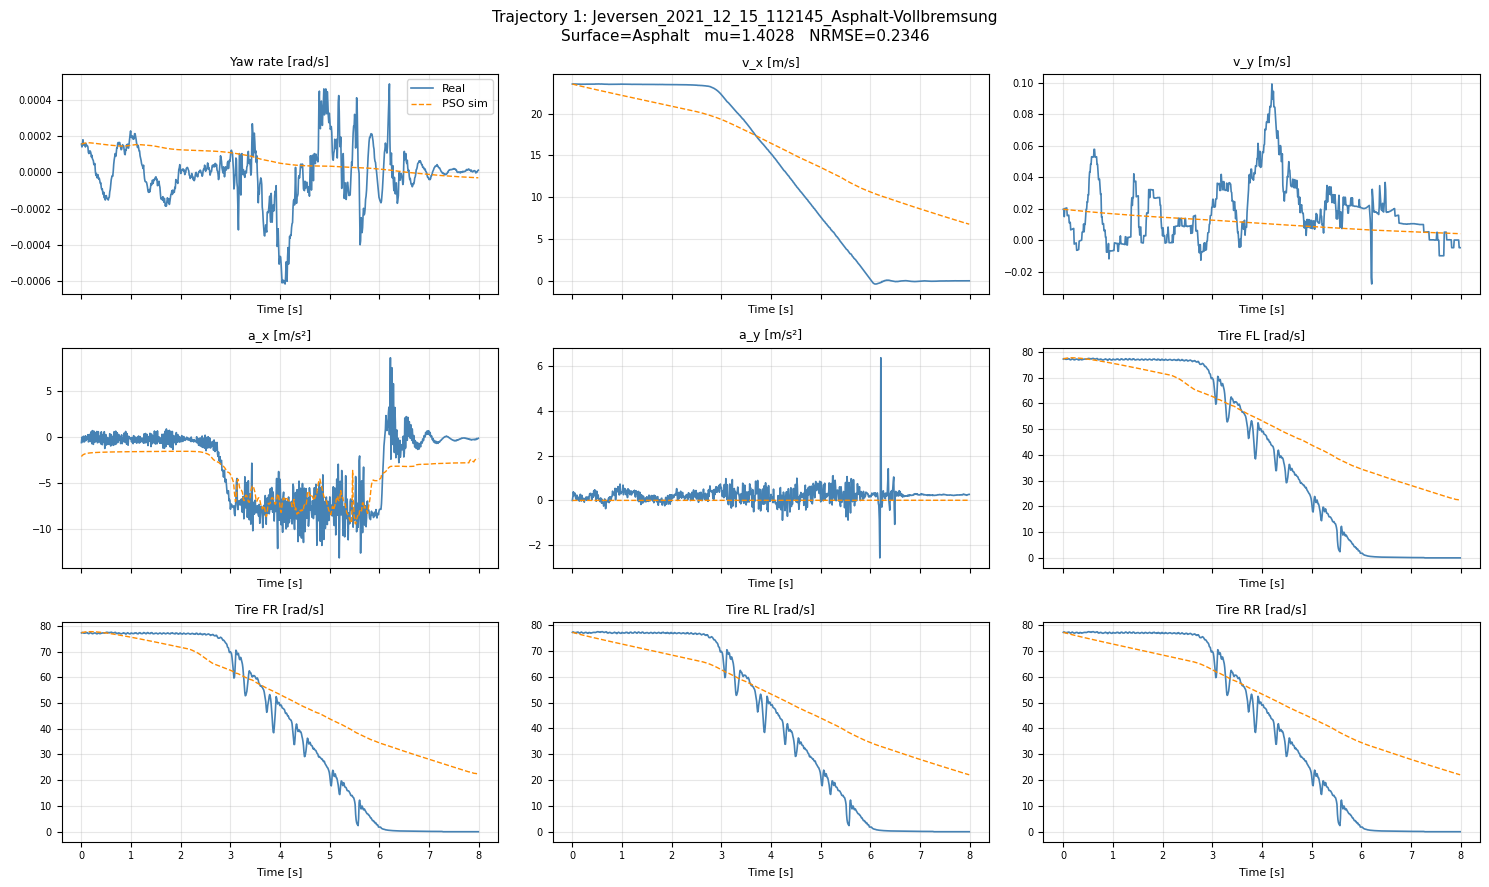

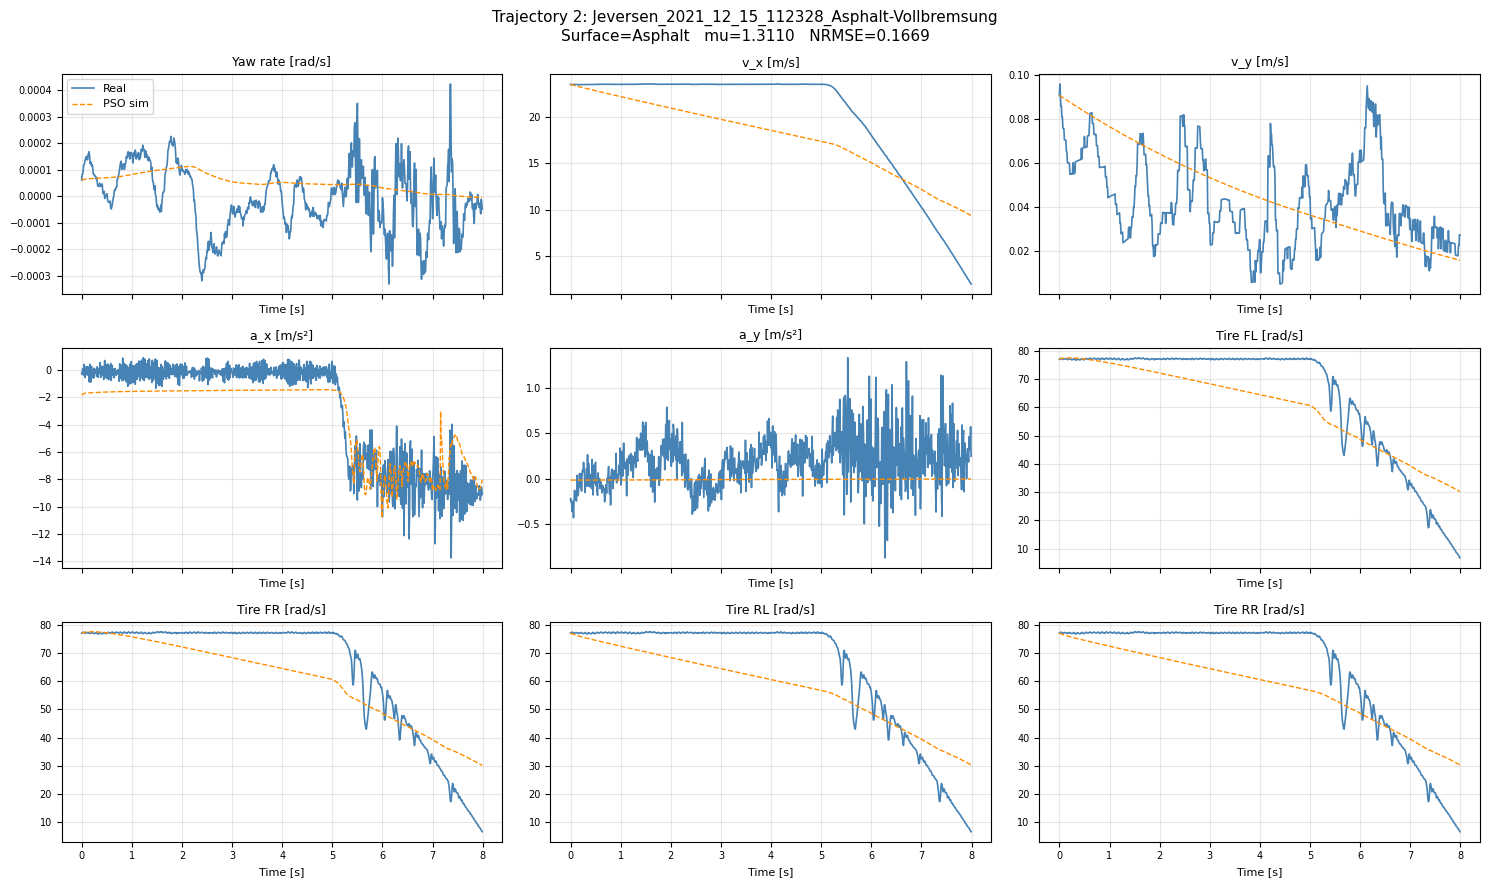

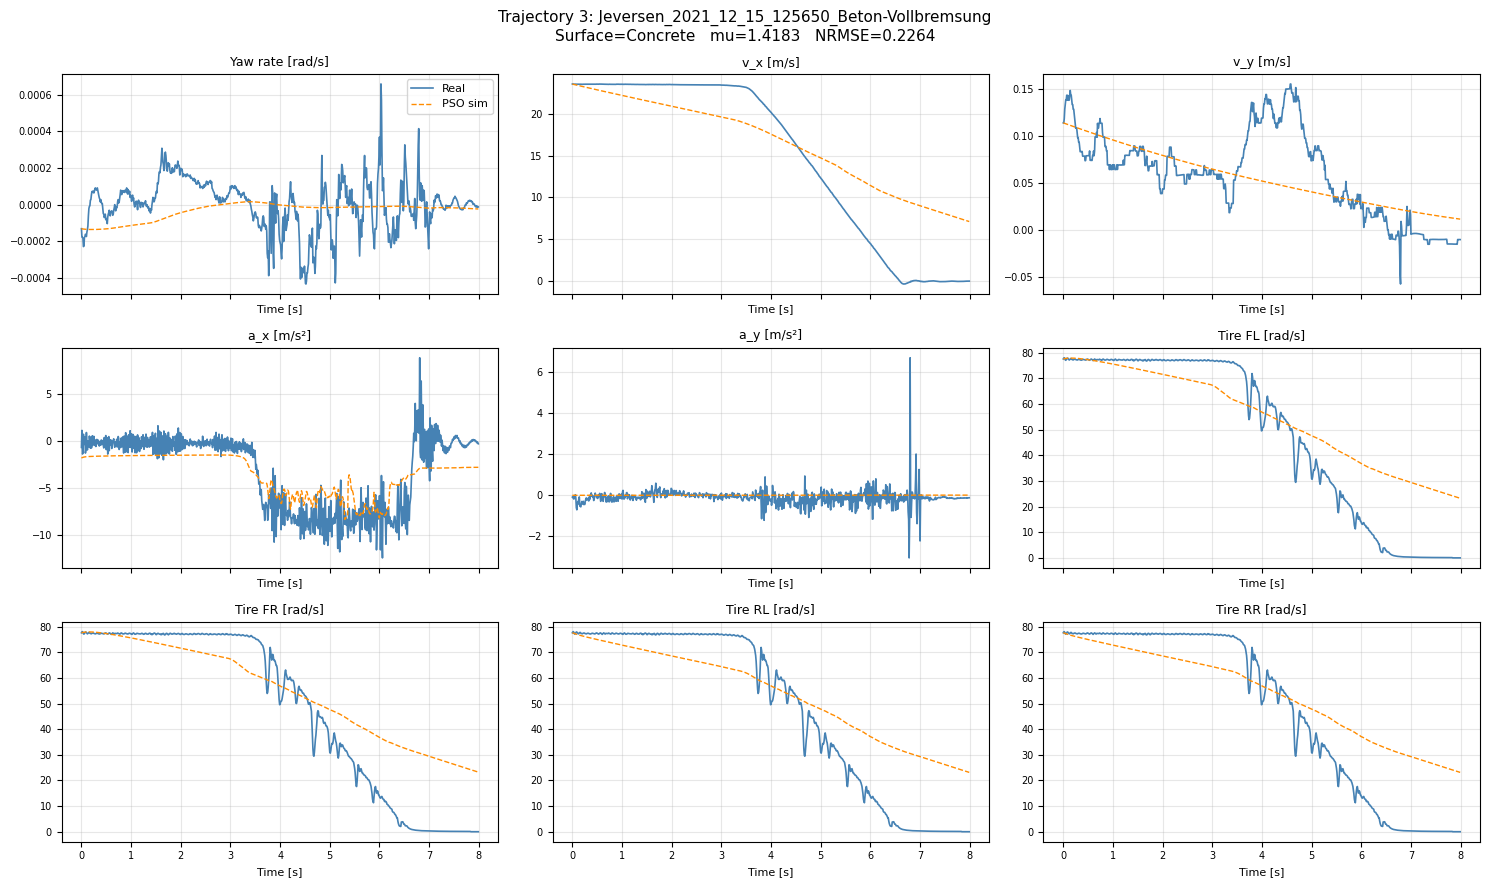

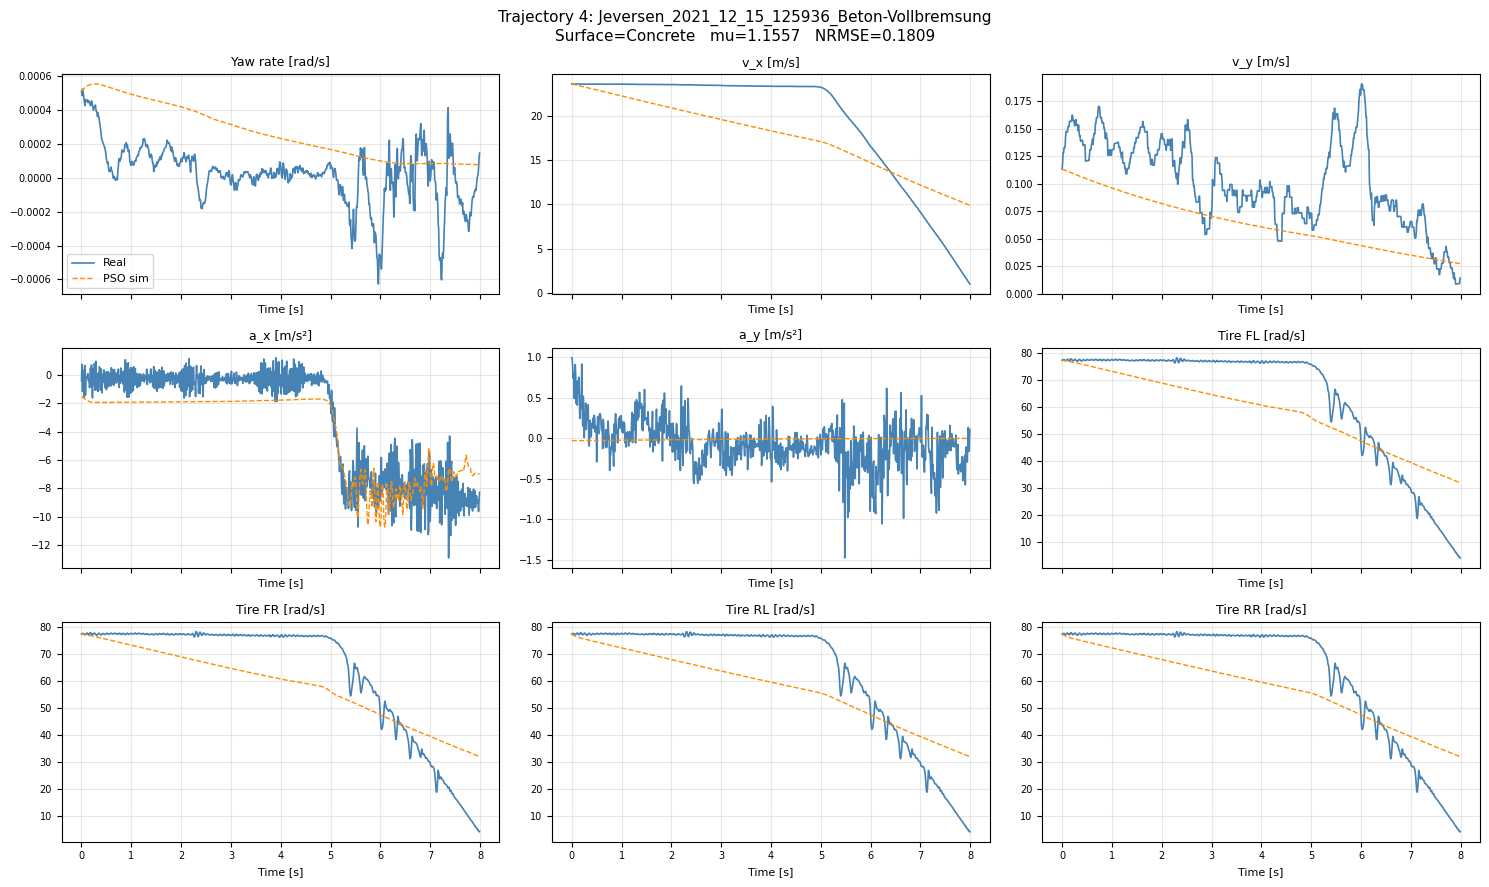

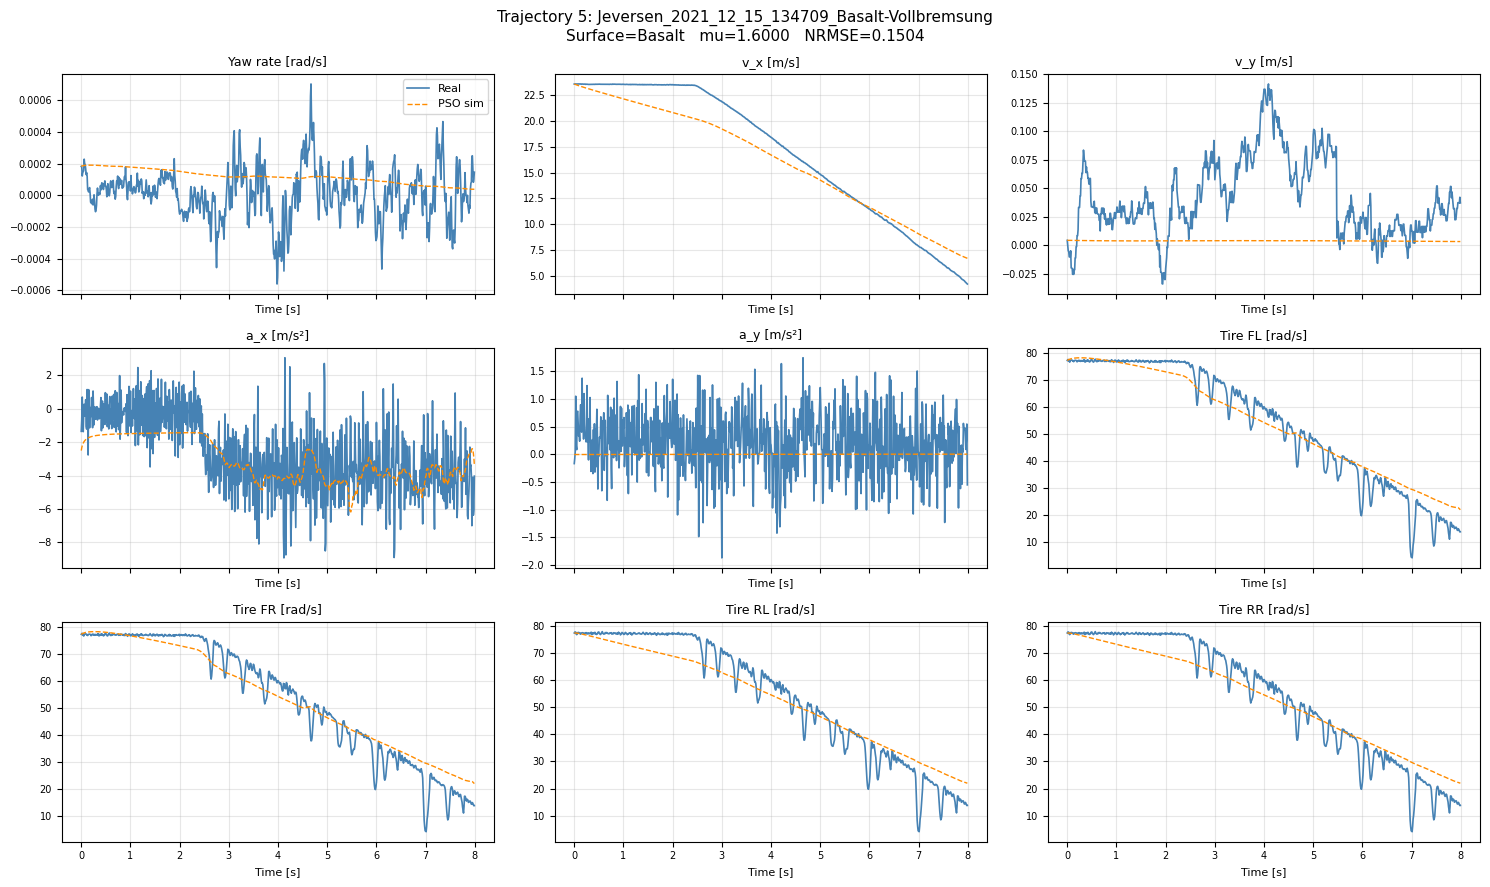

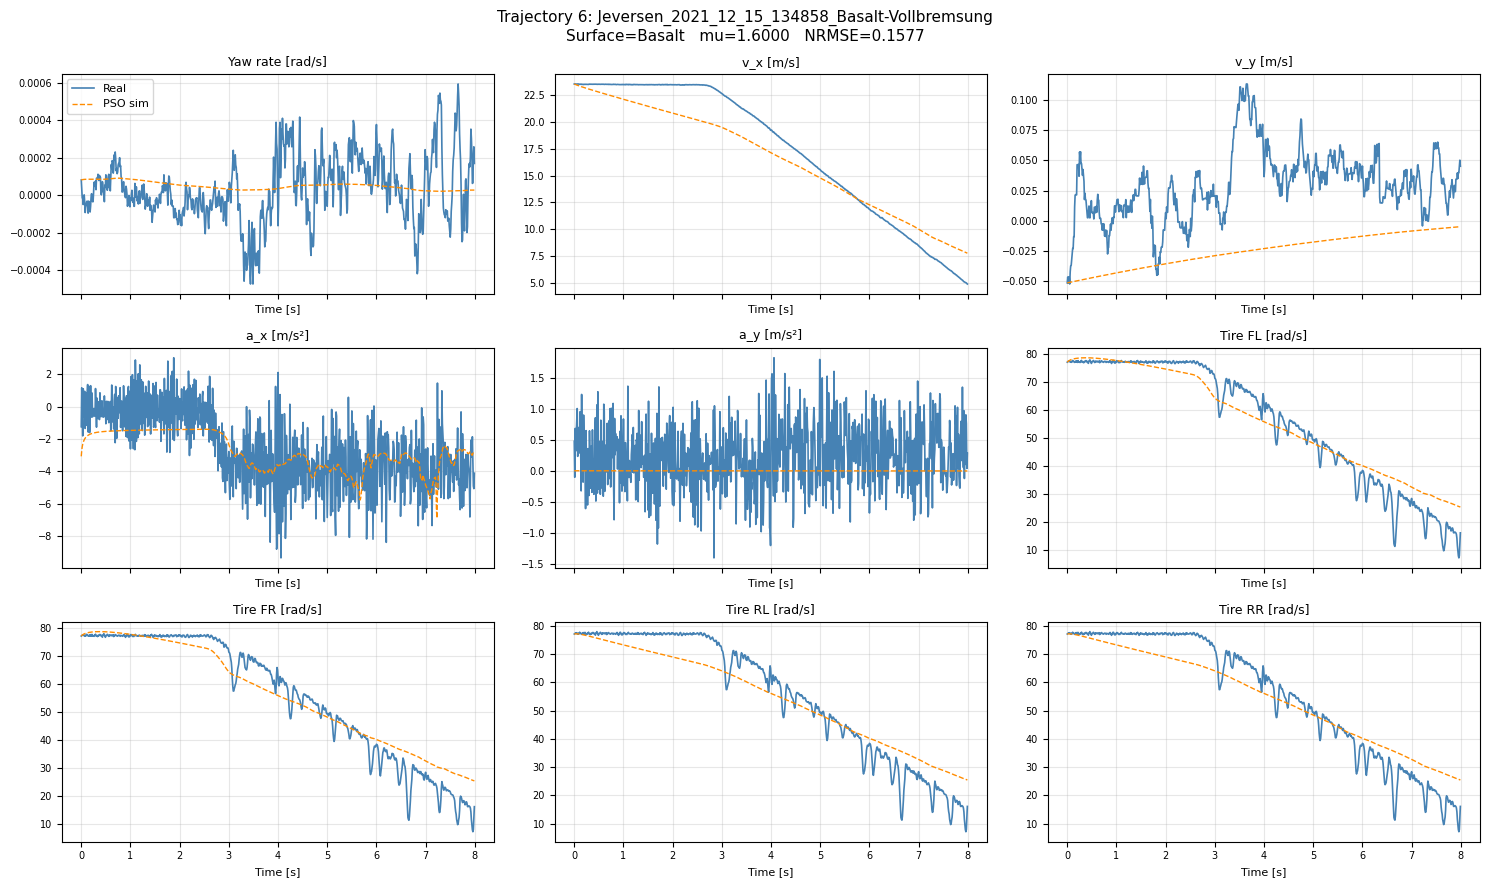

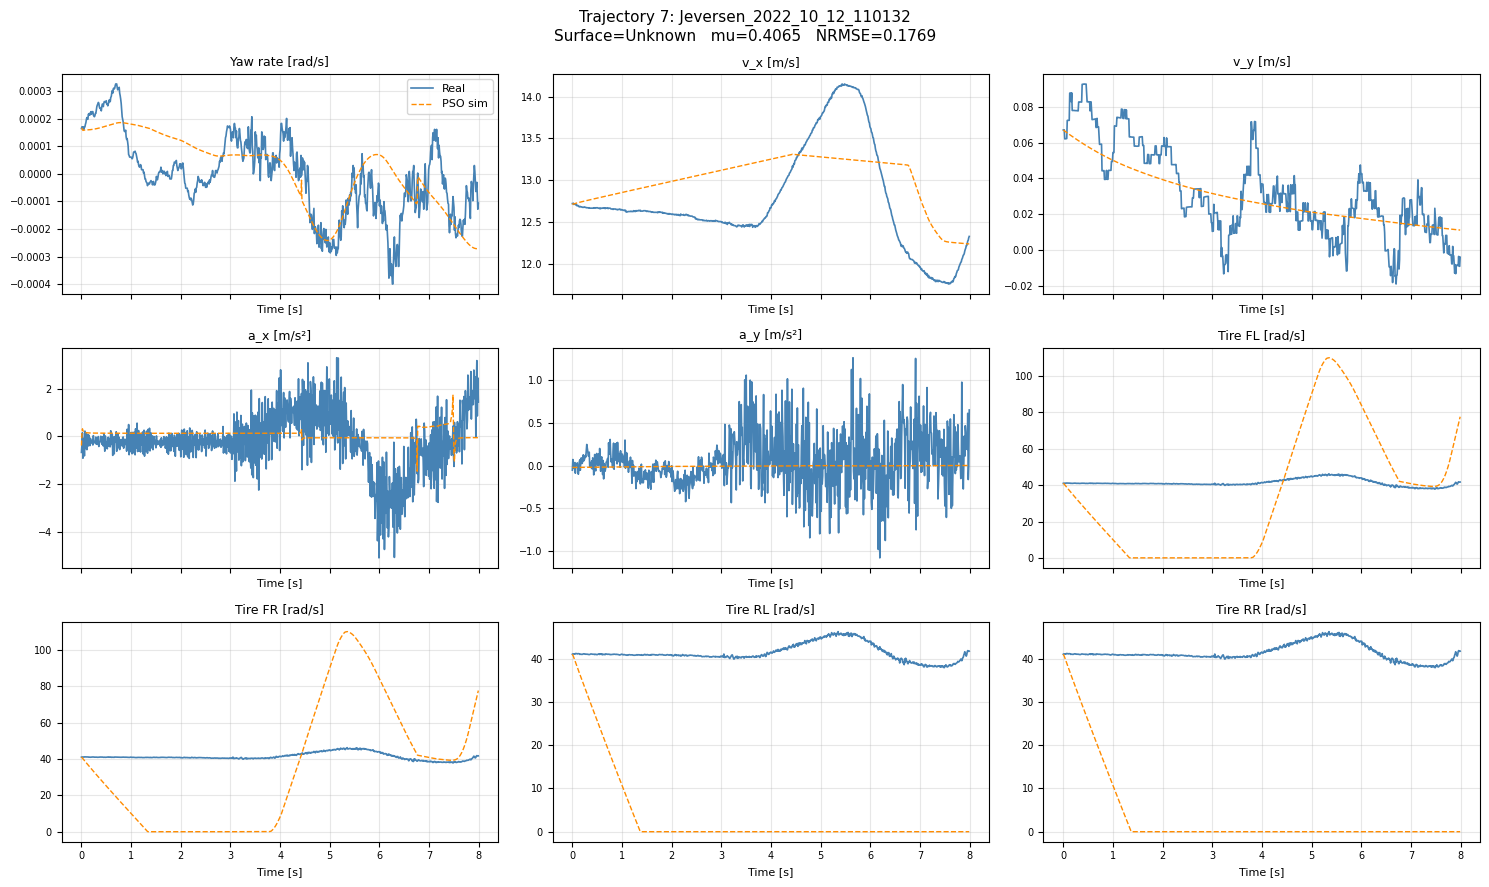

In [8]:
# ── Per-trajectory overlay plots ──────────────────────────────────────────────
CHANNEL_NAMES  = ['Yaw rate [rad/s]', 'v_x [m/s]', 'v_y [m/s]',
                  'a_x [m/s²]',       'a_y [m/s²]',
                  'Tire FL [rad/s]',   'Tire FR [rad/s]',
                  'Tire RL [rad/s]',   'Tire RR [rad/s]']
N_CHANNELS = len(CHANNEL_NAMES)
time_axis  = np.arange(T_SEG) * 0.01  # dt = 10 ms

for i, (traj, y_sim) in enumerate(zip(trajectories, simulated)):
    T = traj['T']
    t = np.arange(T) * 0.01

    fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
    fig.suptitle(
        f'Trajectory {i+1}: {traj["name"]}\n'
        f'Surface={traj["surface"]}   '
        f'mu={mu_lookup.get(traj["name"], traj_params[i]["params"]["mu"]):.4f}   '
        f'NRMSE={nrmse_per_traj[i]:.4f}',
        fontsize=11,
    )

    for ch, ax in enumerate(axes.flat):
        ax.plot(t, traj['y_real'][:T, ch], color='steelblue',  lw=1.2, label='Real')
        ax.plot(t, y_sim[:T, ch],           color='darkorange', lw=1.0, ls='--', label='PSO sim')
        ax.set_title(CHANNEL_NAMES[ch], fontsize=9)
        ax.set_xlabel('Time [s]', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        if ch == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(FIG_DIR / f'traj_{i+1}_{traj["name"]}.png', dpi=150, bbox_inches='tight')
    plt.show()

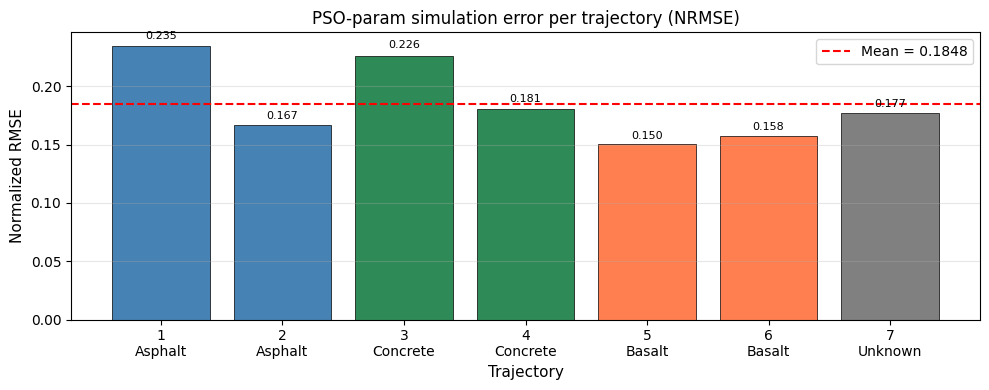

In [9]:

# ── NRMSE bar chart across trajectories ──────────────────────────────────────
labels = [f'{i+1}\n{t["surface"]}' for i, t in enumerate(trajectories)]
colors = {'Asphalt': 'steelblue', 'Concrete': 'seagreen', 'Basalt': 'coral', 'Unknown': 'grey'}
bar_colors = [colors[t['surface']] for t in trajectories]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, nrmse_per_traj, color=bar_colors, edgecolor='k', linewidth=0.5)
ax.axhline(np.mean(nrmse_per_traj), color='red', ls='--', lw=1.5, label=f'Mean = {np.mean(nrmse_per_traj):.4f}')
ax.set_xlabel('Trajectory', fontsize=11)
ax.set_ylabel('Normalized RMSE', fontsize=11)
ax.set_title('PSO-param simulation error per trajectory (NRMSE)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, nrmse_per_traj):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.02, f'{val:.3f}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / 'nrmse_per_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()


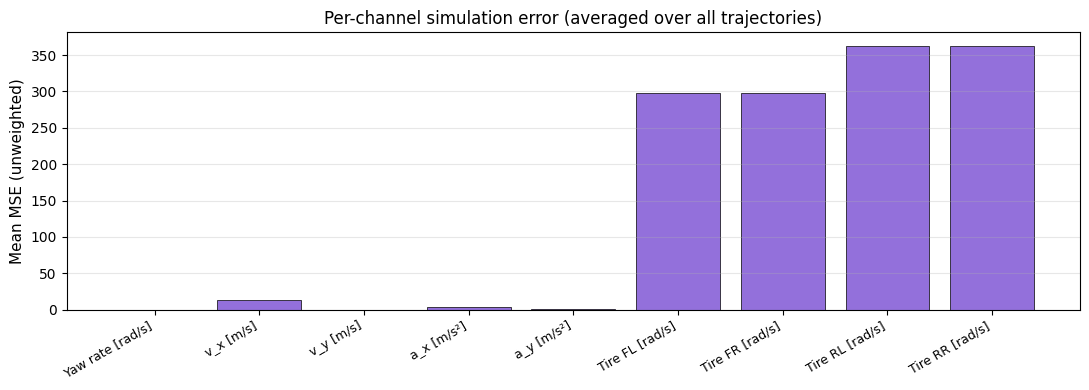

In [10]:
# ── Per-channel MSE across all trajectories (stacked) ────────────────────────
channel_mse = np.zeros((len(trajectories), N_CHANNELS))
for i, (traj, y_sim) in enumerate(zip(trajectories, simulated)):
    T = traj['T']
    channel_mse[i] = np.mean((y_sim[:T] - traj['y_real'][:T])**2, axis=0)

mean_ch_mse = channel_mse.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(N_CHANNELS)
ax.bar(x, mean_ch_mse, color='mediumpurple', edgecolor='k', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(CHANNEL_NAMES, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean MSE (unweighted)', fontsize=11)
ax.set_title('Per-channel simulation error (averaged over all trajectories)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / 'mse_per_channel.png', dpi=150, bbox_inches='tight')
plt.show()

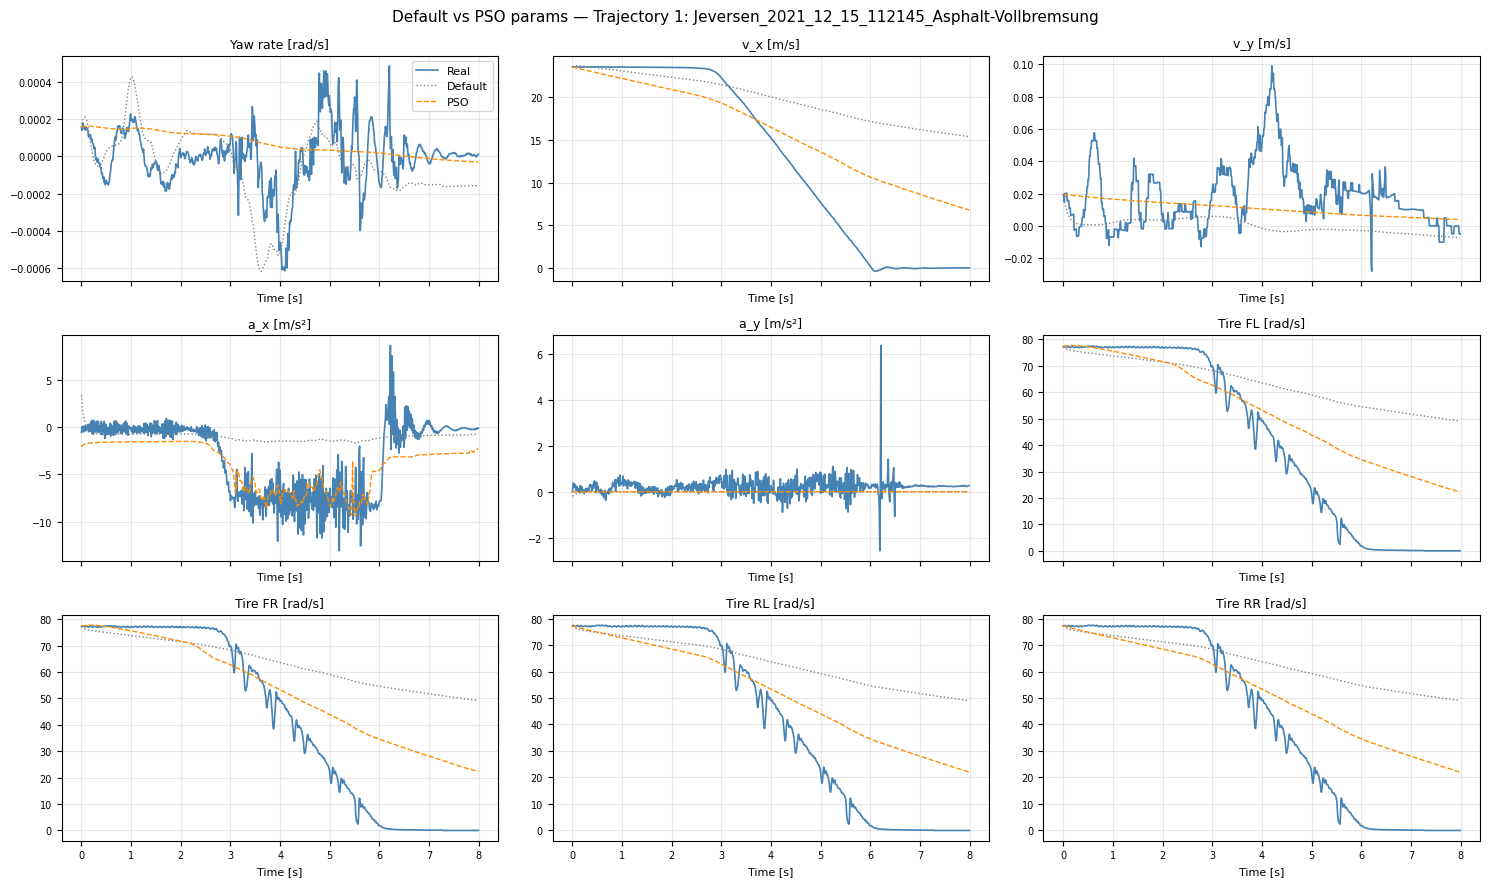

                   Default         PSO         Δ
Weighted NRMSE:     0.3915      0.2346    +40.1%
Physics  only :     0.4199      0.2554    +39.2%
Tire     only :     0.3203      0.1827    +43.0%


In [11]:

# ── (Optional) Compare PSO params vs default params on one trajectory ─────────
COMPARE_IDX = 0   # change to any trajectory index 0..N-1

DEFAULTS = dict(
    mass=1720, Inertia_z=2066, Inertia_tire=28.6, Inertia_engine=0.197,
    air_resistance=0.27, c_1y=1.9e6, c_2y=1.35e5, C_y=1.9, E_y=0.52,
    C_roll1=0.0083, C_roll2=0.0005, radius_tire=0.3116,
    c_1x=2.5e7, c_2x=3.6e6, C_x=1.42, E_x=-9.75, mu=0.8,
)

dp = DEFAULTS
params_arr_def = jnp.array([
    dp['c_1x'], dp['c_2x'], dp['c_1y'], dp['c_2y'],
    dp['C_x'],  dp['C_y'],  dp['E_x'],  dp['E_y'],
    dp['C_roll1'], dp['C_roll2'],
    dp['mass'], dp['Inertia_z'], dp['Inertia_tire'],
    dp['Inertia_engine'], dp['air_resistance'],
], dtype=jnp.float32)
p_inf_def = jnp.array([dp['mu'], dp['air_resistance'], dp['mass']], dtype=jnp.float32)

traj = trajectories[COMPARE_IDX]
y0    = traj['y_real'][0]
state0 = jnp.array([0, 0, 0, y0[0], y0[1], y0[2], y0[5], y0[6], y0[7], y0[8]], dtype=jnp.float32)
controls_arr = jnp.stack([
    traj['controls']['steer_ang'],
    traj['controls']['engine_torque'],
    traj['controls']['break_torque'],
    traj['controls']['gear_transmission'],
], axis=1)

y_sim_def = np.asarray(simulate_trajectory_jit(
    p_inf_def, state0, controls_arr, params_arr_def,
    jnp.arange(traj['T']), dp['radius_tire'],
))

t = np.arange(traj['T']) * 0.01
y_sim_pso = simulated[COMPARE_IDX]

fig, axes = plt.subplots(3, 3, figsize=(15, 9), sharex=True)
fig.suptitle(
    f'Default vs PSO params — Trajectory {COMPARE_IDX+1}: {traj["name"]}',
    fontsize=11,
)
for ch, ax in enumerate(axes.flat):
    ax.plot(t, traj['y_real'][:, ch],  color='steelblue',  lw=1.2, label='Real')
    ax.plot(t, y_sim_def[:, ch],        color='grey',        lw=1.0, ls=':', label='Default')
    ax.plot(t, y_sim_pso[:, ch],        color='darkorange',  lw=1.0, ls='--', label='PSO')
    ax.set_title(CHANNEL_NAMES[ch], fontsize=9)
    ax.set_xlabel('Time [s]', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)
    if ch == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(FIG_DIR / f'default_vs_pso_traj{COMPARE_IDX+1}.png', dpi=150, bbox_inches='tight')
plt.show()

# Weighted NRMSE — consistent with PSO loss
per_ch_rmse_def = np.sqrt(np.mean((y_sim_def - traj['y_real']) ** 2, axis=0))
nrmse_def = float(np.sum(OBS_W_ACTIVE * per_ch_rmse_def[OBS_ACTIVE] / OBS_REF_SCALES[OBS_ACTIVE]) / OBS_W_SUM)

# Physics-only and tire-only breakdown
nrmse_def_phys = float(np.mean(per_ch_rmse_def[:5] / OBS_REF_SCALES[:5]))
nrmse_def_tire = float(np.mean(per_ch_rmse_def[5:] / OBS_REF_SCALES[5:]))
nrmse_pso_phys = float(np.mean(np.sqrt(np.mean((y_sim_pso - traj['y_real'])**2, axis=0))[:5] / OBS_REF_SCALES[:5]))
nrmse_pso_tire = float(np.mean(np.sqrt(np.mean((y_sim_pso - traj['y_real'])**2, axis=0))[5:] / OBS_REF_SCALES[5:]))

print(f'                {"Default":>10s}  {"PSO":>10s}  {"Δ":>8s}')
print(f'Weighted NRMSE: {nrmse_def:10.4f}  {nrmse_per_traj[COMPARE_IDX]:10.4f}  '
      f'{(nrmse_def - nrmse_per_traj[COMPARE_IDX]) / nrmse_def * 100:+7.1f}%')
print(f'Physics  only : {nrmse_def_phys:10.4f}  {nrmse_pso_phys:10.4f}  '
      f'{(nrmse_def_phys - nrmse_pso_phys) / nrmse_def_phys * 100:+7.1f}%')
print(f'Tire     only : {nrmse_def_tire:10.4f}  {nrmse_pso_tire:10.4f}  '
      f'{(nrmse_def_tire - nrmse_pso_tire) / nrmse_def_tire * 100:+7.1f}%')
